In [1]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import copy
import numpy as np
import seaborn as sns
import itertools
import ast
import scipy.stats as stats

from _helper_functions import cb

In [2]:
fn='supp/syntax-fam-Bin2Annotation.pydict.pickle'
with open(fn,'rb') as f:
    Bin2Annotation=pickle.load(f)

In [3]:
fn='supp/OLSName2SyntaxFamily-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    OLSName2SyntaxFamily=pickle.load(f)


In [4]:
fn='supp/OLSEnSeq2Name.pydict.pickle'
with open(fn,'rb') as f:
    OLSEnSeq2Name=pickle.load(f)


In [5]:
fn='supp/SyntaxFamily2OLSName-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    SyntaxFamily2OLSName=pickle.load(f)
    

In [27]:
df=pd.read_pickle(f'supp/endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle')
df

,enhancer-id,enhancer-sites,wt-enhancer-seq,wt-control-name,wt-control-label,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
0,OLS:0,S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,OLS WT,Neural,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0
1,OLS:1,S1-G1F-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6,CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,NaN,0.856235,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-1.100699,"(0, -1)",0
2,OLS:2,S1-G1R-S2-E1F-S3-E2F-S4-G2F-S5-G3F-S6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,NaN,0.777169,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.706492,"(0, 0)",0
3,OLS:3,S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3R-S6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,NaN,NaN,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,-1.486866,"(0, -1)",0
4,OLS:4,S1-G1R-S2-E1R-S3-E2F-S4-G2R-S5-G3F-S6,CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATT...,NaN,NaN,0.518839,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-1.322202,"(0, -1)",0
...,...,...,...,...,...,...,...,...,...,...
460795,OLS:460795,S5-G3R-S4-G2F-S3-E2R-S2-E1F-S1-G1F-S6,CCTATCTTTGCTCAGATATTTTTCGAAATTTCCTTTAACGGAAGTC...,NaN,NaN,1.272434,CCTATTTTTGCTCAAATATTTTTCGAAATTTGCTTTAACGCAAGTC...,NaN,"(1, -1)",1
460796,OLS:460796,S5-G3F-S4-G2F-S3-E2R-S2-E1R-S1-G1F-S6,AAGATAGGTGCTCAGATATTTTTCGAAATTTCCTTTAACTTCCGTC...,NaN,NaN,0.024081,AAAATAGGTGCTCAAATATTTTTCGAAATTTGCTTTAACTTGCGTC...,NaN,"(0, -1)",0
460797,OLS:460797,S5-G3R-S4-G2R-S3-E2R-S2-E1R-S1-G1F-S6,CCTATCTTTGCTCAATATCTTTTCGAAATTTCCTTTAACTTCCGTC...,NaN,NaN,0.005023,CCTATTTTTGCTCAATATTTTTTCGAAATTTGCTTTAACTTGCGTC...,0.872471,"(0, 0)",0
460798,OLS:460798,S5-G3R-S4-G2F-S3-E2R-S2-E1R-S1-G1R-S6,CCTATCTTTGCTCAGATATTTTTCGAAATTTCCTTTAACTTCCGTC...,NaN,NaN,0.180705,CCTATTTTTGCTCAAATATTTTTCGAAATTTGCTTTAACTTGCGTC...,-1.128474,"(0, -1)",0


In [30]:
lookup = pd.read_csv('supp/Supplementary Table 2.csv')
df = df.merge(lookup[['Sequence', 'Syntax Type']].drop_duplicates(), left_on = 'wt-enhancer-seq', right_on = 'Sequence', how = 'left')

/var/folders/5z/t9ftk7ds7890nc05pq3sr3fc0000gn/T/ipykernel_7515/1762590052.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df.loc[df['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']>1,:],x='Syntax Type',y='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled',cut=0,ax=ax,order=groups,palette=palette,inner=None,linewidth=1,scale='width')
/var/folders/5z/t9ftk7ds7890nc05pq3sr3fc0000gn/T/ipykernel_7515/1762590052.py:5: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df.loc[df['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']>1,:],x='Syntax Type',y='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled',cut=0,ax=ax,order=groups,palette=palette,inner=None,lin

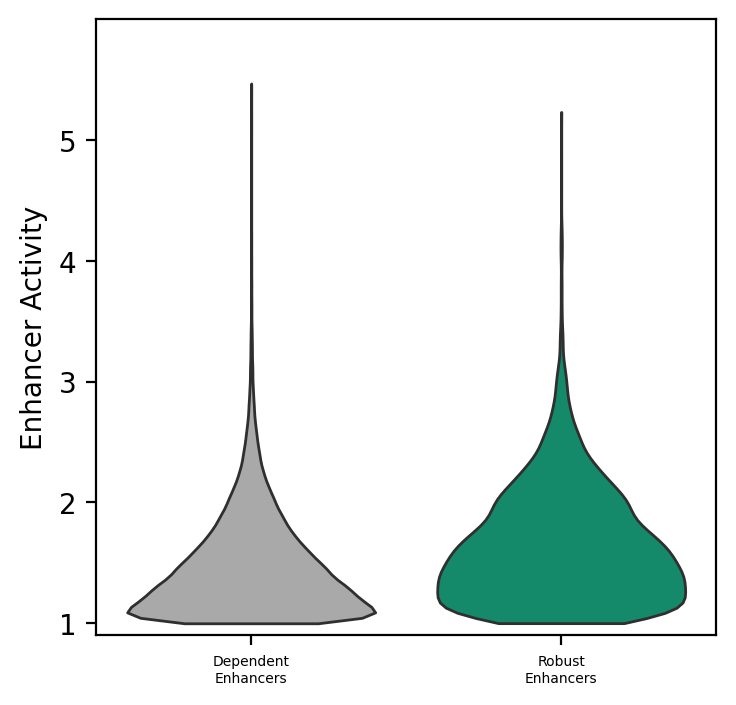

In [32]:
fig,ax=plt.subplots(1,figsize=(4,4),dpi=200)

groups=['Dependent','Robust']
palette=['darkgrey',cb['green']]
sns.violinplot(data=df.loc[df['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']>1,:],x='Syntax Type',y='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled',cut=0,ax=ax,order=groups,palette=palette,inner=None,linewidth=1,scale='width')

ax.set_ylim(.9,6)

ax.set_xticks(range(len(groups)),groups,size=5)
ax.set_ylabel('activity')

ax.set_ylabel('Enhancer Activity')
ax.set_xlabel('')
ax.set_xticks([0,1],labels=['Dependent\nEnhancers','Robust\nEnhancers'])

ax.set_yticks([1,2,3,4,5])